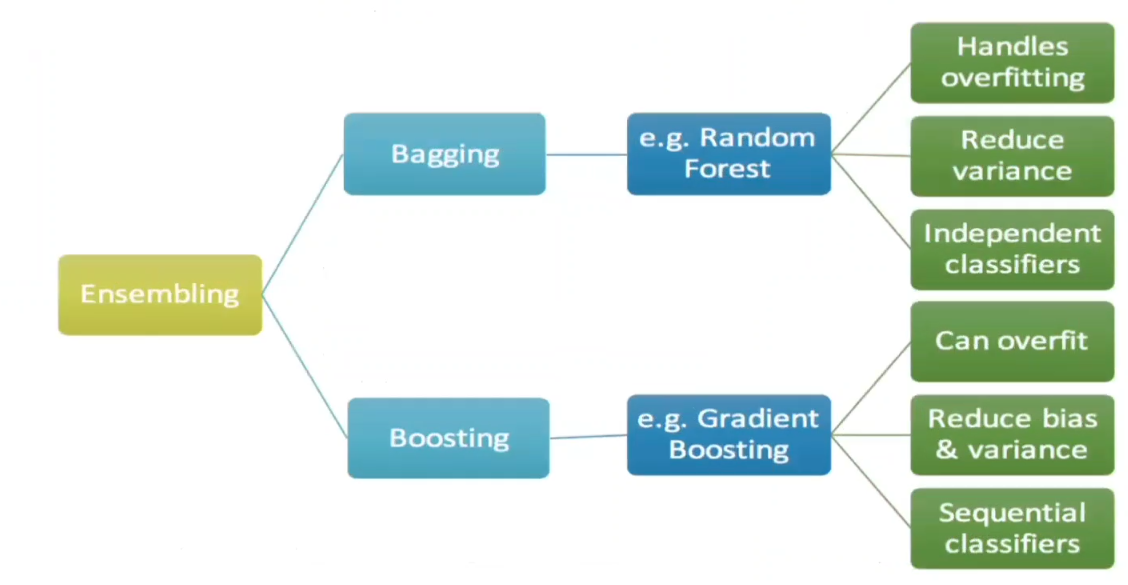

**Ensemble Methods: Purpose and Differences Between Bagging and Boosting**

Ensemble methods aim to create a stronger meta-model by using a series of weak learner models. These methods typically perform better than a single model by combining the learning capacities of multiple models.

**Purpose of Ensemble Methods**
- **Using Weak Learners**: Weak learners are models that perform poorly on their own but can make strong predictions when combined.
- **Creating a Meta Model**: By combining the predictions of multiple weak learners, ensemble methods generally achieve more accurate and reliable results than individual models.

**Bagging and Boosting**
1. **Bagging (Bootstrap Aggregating)**
   - **Working Principle**: Bagging creates random subsets of the dataset and trains a separate model on each subset. Each model is trained on a different "bootstrap" sample of the dataset.
   - **Features**: Bagging includes algorithms like Random Forest. Each model is trained independently, and the results are combined by majority voting or averaging.
   - **Purpose**: To reduce the variance of the model and lower the risk of overfitting.

2. **Boosting**
   - **Working Principle**: Boosting trains weak learners sequentially. Each new model focuses on correcting the errors of the previous models.
   - **Features**: Boosting includes algorithms like XGBoost and AdaBoost. Models learn from each other’s errors, and results are combined through weighted voting or averaging.
   - **Purpose**: To reduce both bias and variance, improving the overall performance of the model.

**Application and Evaluation**
Ensemble methods offer different approaches to improve model performance. Bagging addresses overfitting by increasing randomness and diversity, while boosting aims for more precise predictions through collaboration among models.

**About Dataset**

- **Car_Name**: The name or model of the car.
- **Year**: The year of manufacture of the car.
- **Selling_Price**: The selling price of the car.
- **Present_Price**: The current showroom price of the car.
- **Kms_Driven**: The total kilometers driven by the car up to the point of sale.
- **Fuel_Type**: This column would contain categories such as:
  - **Petrol**: Cars that run on petrol fuel.
  - **Diesel**: Cars that use diesel fuel.
  - **CNG**: Cars that are powered by compressed natural gas.

- **Seller_Type**: This column would indicate the type of seller offering the car, which could be:
  - **Dealer**: A business that sells cars as part of its commercial operations.
  - **Individual**: A private individual selling a personal vehicle.

- **Transmission**: This refers to the gearbox system of the car, with common types being:
  - **Manual**: Cars where the driver manually shifts gears.
  - **Automatic**: Cars where the gear shifting process is automated.

- **Owner**: This would typically be a numeric column indicating the number of previous owners of the car, but if it is categorical, it might have entries such as:
  - **First Owner**: Indicates the car is being sold by its original owner.
  - **Second Owner**: Indicates the car has had one previous owner before the current seller.
  - **Third Owner**, and so on.
  
This data set is for estimating the selling price of a car based on its features.

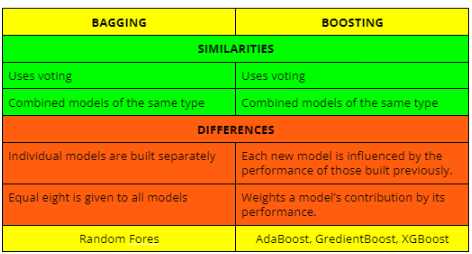

# EDA

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (9,5)
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.width', 1000)

In [115]:
df0 = pd.read_csv("car_dataset.csv")
df = df0.copy()

In [116]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [117]:
df.shape

(301, 9)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [119]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [120]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,301.00,2013.63,2.89,2003.00,2012.00,2014.00,2016.00,2018.00
Selling_Price,301.00,4.66,5.08,0.10,0.90,3.60,6.00,35.00
Present_Price,301.00,7.63,8.64,0.32,1.20,6.40,9.90,92.60
Kms_Driven,301.00,36947.21,38886.88,500.00,15000.00,32000.00,48767.00,500000.00
Owner,301.00,0.04,0.25,0.00,0.00,0.00,0.00,3.00


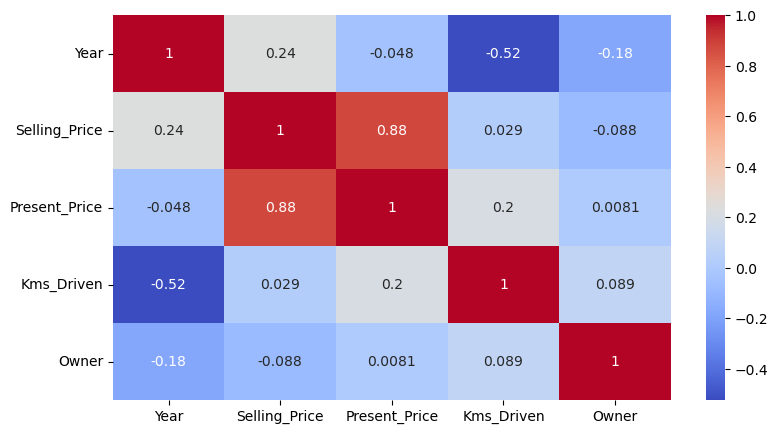

In [121]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [122]:
import plotly.graph_objects as go

corr_matrix = df.select_dtypes(include='number').corr()
heatmap = go.Heatmap(
    z=corr_matrix.values, x=corr_matrix.columns, y=corr_matrix.index,
    colorscale='Magma', zmin=-1, zmax=1, text=corr_matrix.values,
    texttemplate="%{text:.2f}", hoverinfo="none"
)

fig = go.Figure(data=[heatmap], layout=go.Layout(
    title='Corelation Matrix', width=700, height=500))
fig.show()

## Feature Engineering

In [123]:
df["Vehicle_Age"] = 2024 - df.Year

# We are converting the vehicle production year in our dataset into the `Vehicle_Age` feature.

In [124]:
def unique_values(df, columns):
    """Prints unique values and their counts for specific columns in the DataFrame."""

    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = df[column_name].unique()
        value_counts = df[column_name].value_counts()
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [125]:
cat_features = df.select_dtypes(include='object').columns
unique_values(df, cat_features)

# We are observing the number of unique observations in the categorical features.
# The number of unique categorical observations for `car_name` is significantly high compared to the total number of observations in our dataset.

Column: Car_Name
------------------------------
Unique Values (98): ['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS 

In [126]:
df.drop(columns=["Car_Name", "Year"], inplace=True)

In [127]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


<Figure size 1200x600 with 0 Axes>

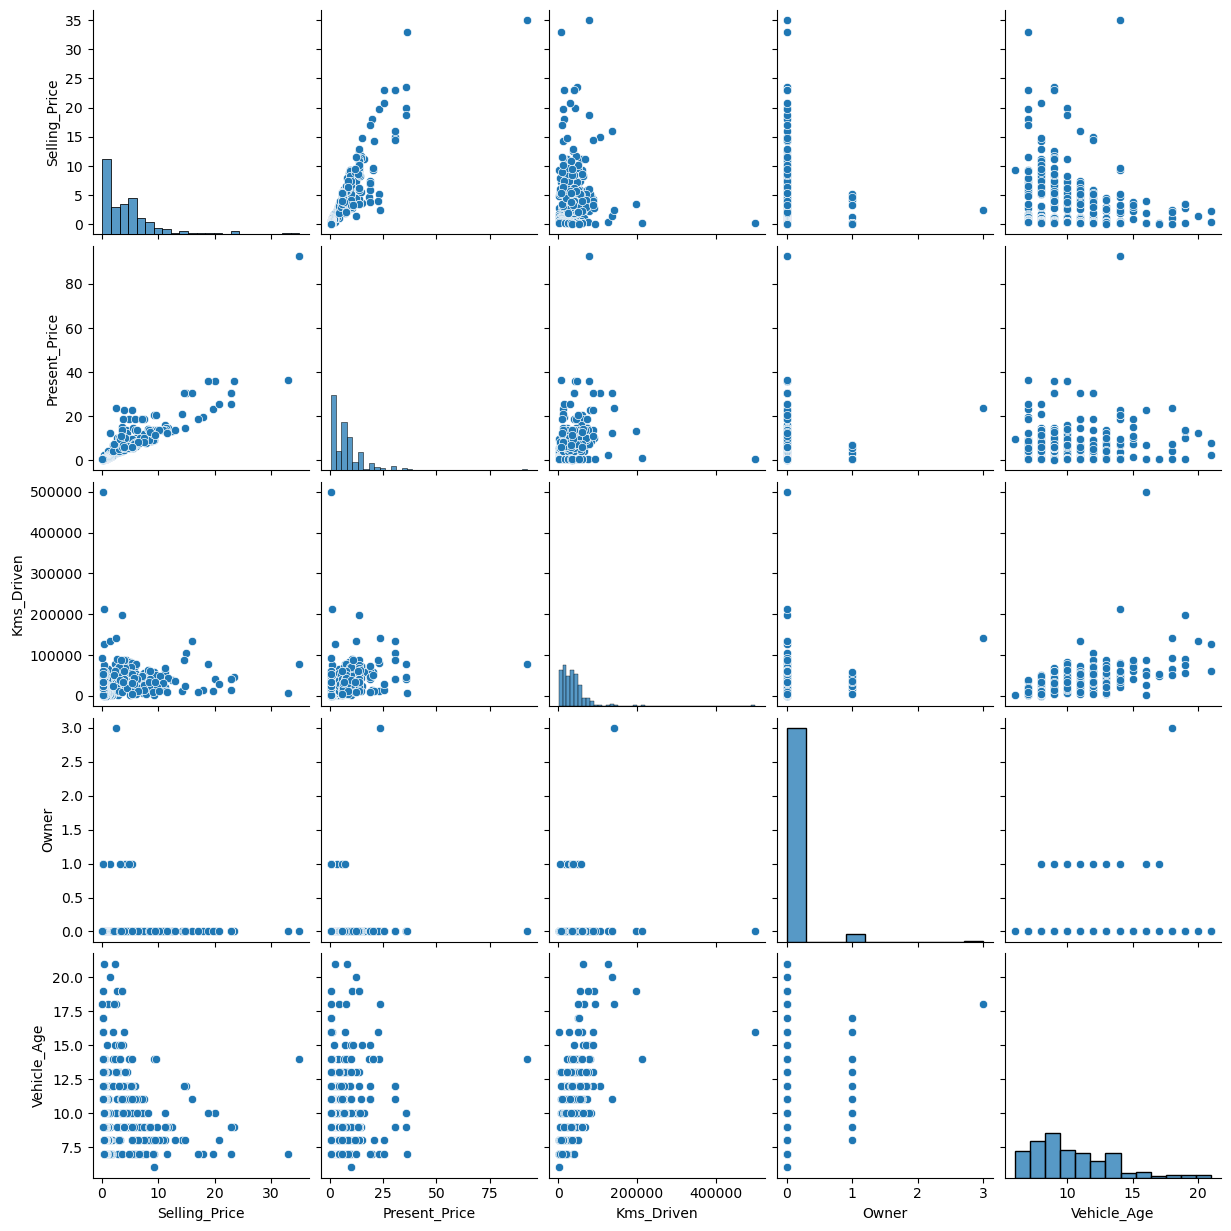

In [128]:
plt.figure(figsize=(12, 6))
sns.pairplot(df, palette="Dark2")

In [129]:
import plotly.figure_factory as ff

fig = ff.create_distplot([df['Selling_Price']], ['Selling Price'],
                         show_hist=True,
                         show_rug=True)

fig.update_layout(
    title_text='Distribution and Box Plot of Selling Prices',  # Title text
    title_font_size=20,  # Title font size
    xaxis_title_text='Selling Price',  # X-axis label
    yaxis_title_text='Density',  # Y-axis label
    template='plotly_white',  # Background color set to white
    width=1000,  # Plot width
    height=500,  # Plot height
    bargap=0.01,  # Space between bars
)

fig.show()

In [130]:
import plotly.graph_objs as go

box_plot = go.Box(y=df['Selling_Price'], name='Selling Price')

fig = go.Figure(data=[box_plot])
fig.update_layout(title='Selling Price Box Plot')
fig.show()

# Modelling

## Train test split

In [131]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

In [132]:
# Outlier handling
df2 = df[df.Selling_Price < 10]
df2.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [133]:
# Labelling
X=df2.drop("Selling_Price", axis=1)
y=df2.Selling_Price

In [134]:
# Split data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=101)

print("Train features shape : ", X_train.shape)
print("Train target shape   : ", y_train.shape)
print("Test features shape  : ", X_test.shape)
print("Test target shape    : ", y_test.shape)

Train features shape :  (218, 7)
Train target shape   :  (218,)
Test features shape  :  (55, 7)
Test target shape    :  (55,)


## AdaBoosting Regressor

**Overview**
AdaBoost is an ensemble technique used to transform weak learners into a strong learner. AdaBoost Regressor applies this approach to regression problems. In an iterative process, the model improves its performance by giving more weight to erroneous predictions and focusing on correcting these errors in successive iterations.

**Key Features**
- **Adaptive Learning**: In each iteration, more weight is given to incorrectly predicted data points.
- **Flexibility**: Can be used with various base regression models.
- **Resistance to Overfitting**: With proper parameter tuning, it reduces the risk of overfitting.

**Applications**
- **Prediction Models**: Forecasting continuous variables such as cost, sales, and demand.
- **Risk Assessment**: Risk prediction in finance and insurance sectors.
- **Time Series Analysis**: Analysis and prediction of time-dependent data.

**Base Estimator**
In regression, the base estimator is often a Decision Tree (DT) regressor, while in classification, it is a classifier. While sources may mention SVM and logistic regression, Decision Trees typically achieve the best scores.

**Differences Between AdaBoost Regressor and AdaBoost Classifier**

AdaBoost has two main variations: AdaBoost Classifier and AdaBoost Regressor. While both are ensemble techniques used to enhance weak learners, they have a fundamental difference: the default `max_depth` parameter values.

- **AdaBoost Classifier**: Typically uses a Decision Tree Classifier as the base learner with a default `max_depth` of **1**. This setting indicates that combining simple models can be effective for classification problems.

- **AdaBoost Regressor**: Uses a Decision Tree Regressor as the base learner with a default `max_depth` of **3**. In regression problems, deeper trees often provide better results, as a single shallow tree may not capture the complexity of the data effectively.

In [135]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [136]:
def train_val(model, X_train, y_train, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    
    scores = {"train": {"R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),                          
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},
    
    "test": {"R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}}
    
    return pd.DataFrame(scores)

In [137]:
cat_features = X.select_dtypes("object").columns
cat_features 

Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')

In [138]:
# Encoding
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder


ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

column_trans = make_column_transformer((ord_enc, cat_features), remainder='passthrough')

In [139]:
from sklearn.tree import DecisionTreeRegressor

In [140]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostRegressor

# from sklearn.tree import DecisionTreeRegressor
# operations = [
#     ("OrdinalEncoder", column_trans),
#     ("Ada_model",
#      AdaBoostRegressor(base_estimator=DecisionTreeRegressor(max_depth=3),
#                        random_state=101))

operations = [("OrdinalEncoder", column_trans),
              ("Ada_model", AdaBoostRegressor(random_state=101))]

# Base model
pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

# The AdaBoostRegressor algorithm uses base_estimator=DecisionTreeRegressor(max_depth=3) by default.

# In AdaBoostRegressor, predictions from each tree are weighted to produce the final prediction.

# For example, consider a prediction for a sample:
# 1. Tree 1 predicts 4 for this sample;
# 2. Tree 2 predicts 6;
# 3. Tree 3 predicts 8.

# Assume the weights are as follows: Tree 1 has a weight of 1.5, Tree 2 has a weight of 0.5, and Tree 3 has a weight of 1.

# The prediction is calculated by considering these weights as follows:
# pred = (Tree 1 prediction x Tree 1 weight + Tree 2 prediction x Tree 2 weight + Tree 3 prediction x Tree 3 weight) /
#        (Tree 1 weight + Tree 2 weight + Tree 3 weight)
# pred = (4*1.5 + 6*0.5 + 8*1) / (1.5 + 0.5 + 1) = 5.67


Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('Ada_model', AdaBoostRegressor(random_state=101))])

In [141]:
train_val(pipe_model, X_train, y_train, X_test, y_test)

,train,test
R2,0.96,0.96
mae,0.43,0.44
mse,0.30,0.35
rmse,0.55,0.59


* In booting algorithms **rmse has more importance than R2**.

* So, we should focuse on **harmony between rmse scores of tran and test data**. 

* If **there are a harmony**, **there isn't overfitting problem**.

In [142]:
y_pred_ada = pipe_model.predict(X_test)
y_pred_ada

array([5.77972222, 5.54807692, 6.65247934, 7.22843137, 0.65454545,
       4.32162162, 4.715     , 6.65247934, 0.605     , 4.8297619 ,
       0.632     , 0.605     , 4.55238095, 0.588     , 1.20714286,
       3.48125   , 0.588     , 4.8297619 , 8.07236842, 1.2       ,
       0.605     , 0.632     , 8.22058824, 1.1625    , 1.16      ,
       1.20714286, 0.605     , 5.27323529, 0.605     , 5.77      ,
       0.605     , 5.27323529, 5.40448718, 7.81585366, 8.07236842,
       7.99830508, 1.20714286, 3.96079208, 0.588     , 3.01388889,
       4.6380303 , 1.2       , 5.54807692, 2.84615385, 5.54807692,
       0.605     , 0.65454545, 3.62688312, 2.9       , 4.55238095,
       6.87315385, 0.65454545, 0.605     , 7.18285714, 3.00222222])

In [143]:
# CV
from sklearn.model_selection import cross_validate, cross_val_score

operations = [("OrdinalEncoder", column_trans),
              ("Ada_model", AdaBoostRegressor(random_state=101))]

model = Pipeline(steps=operations)

scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=[
                            'r2', 'neg_mean_absolute_error',
                            'neg_mean_squared_error',
                            'neg_root_mean_squared_error'
                        ],
                        cv=10,
                        return_train_score=True)
pd.DataFrame(scores)
pd.DataFrame(scores).mean()[2:]

test_r2                              0.91
train_r2                             0.96
test_neg_mean_absolute_error        -0.53
train_neg_mean_absolute_error       -0.40
test_neg_mean_squared_error         -0.58
train_neg_mean_squared_error        -0.27
test_neg_root_mean_squared_error    -0.75
train_neg_root_mean_squared_error   -0.52
dtype: float64

**Principles of AdaBoost Regressor and the Effects of Parameter Tuning**

**AdaBoost Regressor and Number of Trees**
AdaBoost combines a series of decision trees to make predictions. As the number of trees in a model increases, predictions generally become more accurate. However, when the dataset is small, the effectiveness of these models may be limited. For example, a score of 5.93 is achieved with 50 trees, but increasing the number of trees might lead to a score of 6.5 or higher.

**Weighted Predictions**
AdaBoost generates the final prediction by weighting the predictions of each tree. Initially, a few trees may have larger weights than others. This relates to the weights determined based on each tree's performance on the training dataset.

**Learning Rate**
The learning rate controls the size of adjustments made at each step. A lower learning rate means smaller steps and generally requires more trees. For instance, reducing the learning rate may necessitate an increase in the number of trees to achieve more accurate predictions.

**Loss Parameter**
AdaBoostRegressor offers three loss functions: "linear", "square", and "exponential". Each provides a different method for calculating errors:

- **Linear**: Based on the difference between predictions and actual values, with linear errors.
- **Square**: Squares the errors, giving more weight to larger errors.
- **Exponential**: The classic AdaBoost error function, generally not used for regression.

Determining the most suitable loss function for a given dataset typically involves cross-validation or other model selection methods.

**Conclusion**
The effectiveness of AdaBoost depends on both the size of the **dataset and the parameter settings**. Careful tuning of parameters such as the **number of trees**, **learning rate**, and **loss function** can significantly impact the model's performance.

- **AdaBoostRegressor:**
  - **Loss**: "linear", "square". In regression problems, these loss functions adjust the model's response to errors.

### AdaBoost Model Tuning - Gridsearch

In [144]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

In [145]:
param_grid = {"Ada_model__n_estimators":[50,100, 150,200],
              "Ada_model__learning_rate":[0.1, 0.5, 0.8, 1],
              "Ada_model__loss": ["linear", "square"]
            }

# - **AdaBoost Regressor:**
#   - **Estimator**: In contrast to classification, where `DecisionTreeClassifier(max_depth=1)` is used, for regression, it uses `DecisionTreeRegressor(max_depth=3)`.
#   - **Loss Function**: The loss function determines how the weights of the trees are calculated. The default is "linear", but the optimal loss function should be identified using grid search.
#   - **Leaf Splitting Criteria**: For classification, Gini impurity is used, while for regression, mean squared error (MSE) is considered.

In [146]:
base_estimator=DecisionTreeRegressor(max_depth=2)

operations = [("OrdinalEncoder", column_trans), ("Ada_model", AdaBoostRegressor(estimator=base_estimator, 
                                                                                random_state=101))]

model = Pipeline(steps=operations)

grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          n_jobs = -1,
                          return_train_score=True).fit(X_train,y_train)

# - **To Address Overfitting**: You can also adjust the estimator's hyperparameters to mitigate overfitting. Here, we adjusted the `max_depth` of the base estimator to 2, and this resolved our concerns about overfitting.

In [147]:
grid_model.best_params_

{'Ada_model__learning_rate': 1,
 'Ada_model__loss': 'linear',
 'Ada_model__n_estimators': 50}

In [148]:
grid_model.best_estimator_

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('Ada_model',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=2),
                                   learning_rate=1, random_state=101))])

In [149]:
y_pred = grid_model.predict(X_test)

ada_R2 = r2_score(y_test, y_pred)
ada_mae = mean_absolute_error(y_test, y_pred)
ada_mse = mean_squared_error(y_test, y_pred)
ada_rmse = mean_squared_error(y_test, y_pred, squared=False)
train_val(grid_model, X_train, y_train, X_test, y_test)

,train,test
R2,0.90,0.92
mae,0.66,0.66
mse,0.66,0.67
rmse,0.81,0.82


* There is a good **harmony between rmse scores** at the best model.


* So, there **isn't an overfitting problem** in AdaBoost  model. 

### Feature importance

In [150]:
features = pipe_model["OrdinalEncoder"].get_feature_names_out()
features

array(['ordinalencoder__Fuel_Type', 'ordinalencoder__Seller_Type',
       'ordinalencoder__Transmission', 'remainder__Present_Price',
       'remainder__Kms_Driven', 'remainder__Owner',
       'remainder__Vehicle_Age'], dtype=object)

In [151]:
new_features = [i.replace("ordinalencoder__","").replace("remainder__", "") for i in features]
new_features

['Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Present_Price',
 'Kms_Driven',
 'Owner',
 'Vehicle_Age']

In [152]:
operations = [("OrdinalEncoder", column_trans),
              ("Ada_model",
               AdaBoostRegressor(estimator=base_estimator,
                                 loss='linear',
                                 n_estimators=50,
                                 learning_rate=1,
                                 random_state=101))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('Ada_model',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=2),
                                   learning_rate=1, random_state=101))])

In [153]:
pipe_model["Ada_model"].feature_importances_

array([0.08401343, 0.04126417, 0.00995427, 0.56333482, 0.09789195,
       0.        , 0.20354136])

In [154]:
imp_feats = pd.DataFrame(data=pipe_model["Ada_model"].feature_importances_,columns=['Ada_Importance'], index=new_features)
ada_imp_feats = imp_feats.sort_values('Ada_Importance', ascending=False)
ada_imp_feats

,Ada_Importance
Present_Price,0.56
Vehicle_Age,0.20
Kms_Driven,0.10
Fuel_Type,0.08
Seller_Type,0.04
Transmission,0.01
Owner,0.00


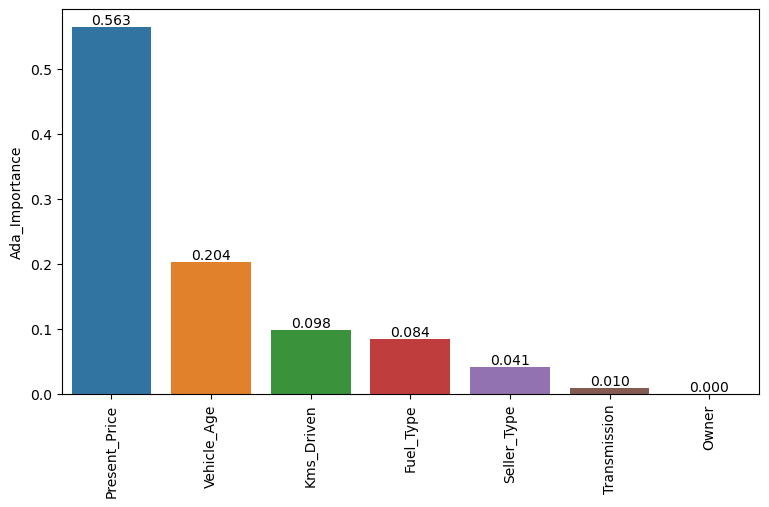

In [155]:
ax = sns.barplot(data=ada_imp_feats, x=ada_imp_feats.index, y='Ada_Importance')
ax.bar_label(ax.containers[0],fmt="%.3f")
plt.xticks(rotation=90);

## Gradient Boosting Regressor

**Overview**
The Gradient Boosting Regressor is a machine learning technique that trains weak learners (typically decision trees) sequentially to build a strong prediction model. Each new model focuses on correcting the errors made by the previous models.

**Key Features**
- **Sequential Learning**: Each tree tries to correct the errors of the previous trees.
- **Suitable for Complex Datasets**: Can effectively handle various and complex data structures.
- **Flexibility**: Customizable with different loss functions and numerous hyperparameters.

**Important Parameters**
- **n_estimators**: Total number of trees. More trees generally lead to better performance but also increase the risk of overfitting.
- **learning_rate**: Determines the contribution of each tree. A lower value usually means slower learning but potentially better performance.
- **max_depth**: Maximum depth of the trees. Deeper trees can make the model more complex.
- **min_samples_split**: Minimum number of samples required to split an internal node.
- **min_samples_leaf**: Minimum number of samples required to be at a leaf node.
- **max_features**: Maximum number of features to consider for finding the best split.
- **loss**: The loss function used for optimization. For example, `squared_error` is a common choice for regression.

**Applications**
- **Price Prediction**: Predicting prices in real estate, automotive, and other areas.
- **Risk Assessment**: Risk evaluation in financial analysis.
- **Time Series Forecasting**: Forecasting economic data, weather conditions, and other time series data.

In [156]:
from sklearn.ensemble import GradientBoostingRegressor

In [157]:
from sklearn.ensemble import GradientBoostingRegressor

operations = [("OrdinalEncoder", column_trans), ("GB_model", GradientBoostingRegressor(random_state=101))]

# Base GB Model
pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('GB_model', GradientBoostingRegressor(random_state=101))])

- In regression problems, the average of all observations in the data is computed. This average value is used as the starting point for all vehicles.

- The differences (residuals) between these constant starting values and the actual values are calculated, and the model attempts to minimize these residuals to be close to zero.

- As in classification, the residual values computed in each tree are multiplied by the learning rate and added to the starting value to make predictions.

- In the example below, let's assume there are 3 examples in our data. The first car costs 50 TL, the second car costs 100 TL, and the third car costs 150 TL.

- The starting value for the cars will be the average value of all cars (100 TL).

- The values found in each tree will be added to this starting value to update the predictions.

**Dataset and Starting Values:**
- First car price: **50 TL**
- Second car price: **100 TL**
- Third car price: **150 TL**

**Calculating Average Starting Value:**
- Average value of all cars (starting value): **(50 + 100 + 150) / 3 = 100 TL**

**Residual Calculation and Updates:**
1. For the first car:
   - Actual price: **50 TL**
   - Starting prediction: **100 TL**
   - Residual: **50 - 100 = -50**
   - Update with learning rate: **0.1 * -50 = -5**
   - Updated prediction: **100 - 5 = 95 TL**
   
   **It is look like when agent feel negative trend, it try to go on that direction for reaching to optimum value (trough point of valley).**

2. For the second car:
   - Actual price: **100 TL**
   - Starting prediction: **100 TL**
   - Residual: **100 - 100 = 0** (No change)
   - Updated prediction: **100 + 0 = 100 TL**

3. For the third car:
   - Actual price: **150 TL**
   - Starting prediction: **100 TL**
   - Residual: **150 - 100 = 50**
   - Update with learning rate: **0.1 * 50 = 5**
   - Updated prediction: **100 + 5 = 105 TL**

**Explanation:**
- **Residuals:** The difference between the actual value and the predicted value at each step.
- **Updates:** The residual value multiplied by the learning rate is added to the starting prediction.
- The model updates its predictions using these residual values at each iteration and tries to reduce the error rate.

In [158]:
train_val(pipe_model, X_train, y_train, X_test, y_test)

,train,test
R2,0.99,0.97
mae,0.17,0.36
mse,0.06,0.27
rmse,0.25,0.52


In [159]:
# CV
operations = [("OrdinalEncoder", column_trans), ("GB_model", GradientBoostingRegressor(random_state=101))]

model = Pipeline(steps=operations)
scores = cross_validate(model, X_train, y_train, scoring=['r2', 
            'neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'], cv =10,
                       return_train_score=True)

pd.DataFrame(scores).mean()[2:]

test_r2                              0.93
train_r2                             0.99
test_neg_mean_absolute_error        -0.45
train_neg_mean_absolute_error       -0.17
test_neg_mean_squared_error         -0.42
train_neg_mean_squared_error        -0.06
test_neg_root_mean_squared_error    -0.63
train_neg_root_mean_squared_error   -0.24
dtype: float64

### GradientBoost Model Tuning - Gridsearch

**Gradient Boosting Regressor Parameters**

**Main Parameters and Their Functions**

- **loss**: Specifies the loss function to be optimized. `'squared_error'` represents the mean squared error and is commonly used for regression.

- **learning_rate**: Used to scale the contribution of each tree. A lower value requires more trees but usually provides better performance.

- **n_estimators**: Indicates the total number of trees in the ensemble.

- **subsample**: Specifies the fraction of training samples to be used for fitting each tree. A value of 1.0 means all training samples are used, while values less than 1.0 can be used for Stochastic Gradient Boosting.

- **criterion**: Specifies the quality function for splits. `'friedman_mse'` often provides the best performance.

- **min_samples_split**: The minimum number of samples required to split an internal node.

- **min_samples_leaf**: The minimum number of samples required to be at a leaf node.

- **max_depth**: Specifies the maximum depth of the trees. Increasing depth increases model complexity.

- **max_features**: The number or proportion of features to consider when looking for the best split.

- **alpha**: Specifies the quantile value for `'huber'` and `'quantile'` loss functions.

- **verbose**: Controls the amount of information printed during the fitting process.

- **warm_start**: When set to True, continues fitting from the previous solution.

- **validation_fraction**: The proportion of training data to set aside for **early stopping**.

- **n_iter_no_change**: The number of **iterations** with no improvement in validation score before **stopping early**.

- **tol**: Tolerance value for early stopping. If the change in validation score between iterations is less than this value, the algorithm stops.

- **ccp_alpha**: The complexity parameter for Minimum Cost Complexity Pruning.

- **GradientBoostingClassifier/Regressor:**
  - **Classification (GradientBoostingClassifier)**: Uses loss functions like deviance (logarithmic loss -->Log-loss) and exponential. These manage classification errors.
  - **Regression (GradientBoostingRegressor)**: Uses loss functions like ls (least squares), lad (least absolute deviations), huber, and quantile. These determine how regression errors are handled.

In [160]:
param_grid = {"GB_model__n_estimators":[35,50], 
              "GB_model__subsample":[0.7, 0.8, 1], 
              "GB_model__max_features" : [4,5,6],
              "GB_model__learning_rate": [0.1, 0.02, 0.03, 0.05], 
              'GB_model__max_depth':[1, 2, 3],
              'GB_model__min_samples_split':[1,2,3],
              'GB_model__min_samples_leaf':[1,2]}

# - The main difference from classification is that `loss='squared_error'` is used. In classification, this was `log_loss`.

In [161]:
operations = [("OrdinalEncoder", column_trans), ("GB_model", GradientBoostingRegressor(random_state=101))]

model = Pipeline(steps=operations)

grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=5,
                          n_jobs = -1,
                          return_train_score=True).fit(X_train, y_train)

In [162]:
grid_model.best_params_

{'GB_model__learning_rate': 0.1,
 'GB_model__max_depth': 3,
 'GB_model__max_features': 6,
 'GB_model__min_samples_leaf': 1,
 'GB_model__min_samples_split': 2,
 'GB_model__n_estimators': 50,
 'GB_model__subsample': 0.7}

In [163]:
grid_model.best_estimator_

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('GB_model',
                 GradientBoostingRegressor(max_features=6, n_estimators=50,
                                           random_state=101, subsample=0.7))])

In [164]:
grid_model.best_score_

-0.5991215454463278

In [165]:
train_val(grid_model, X_train, y_train, X_test, y_test)

,train,test
R2,0.98,0.97
mae,0.26,0.32
mse,0.12,0.21
rmse,0.35,0.46


In [166]:
# CV
operations = [("OrdinalEncoder", column_trans),
              ("GB_model",
               GradientBoostingRegressor(learning_rate=0.05, max_depth=2, max_features=6,
                          n_estimators=50, random_state=101, subsample=0.7))]

model = Pipeline(steps=operations)

scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=[
                            'r2', 'neg_mean_absolute_error',
                            'neg_mean_squared_error',
                            'neg_root_mean_squared_error'
                        ],
                        cv=10,
                        return_train_score=True)
pd.DataFrame(scores).mean()[2:]

test_r2                              0.88
train_r2                             0.92
test_neg_mean_absolute_error        -0.64
train_neg_mean_absolute_error       -0.53
test_neg_mean_squared_error         -0.82
train_neg_mean_squared_error        -0.56
test_neg_root_mean_squared_error    -0.89
train_neg_root_mean_squared_error   -0.75
dtype: float64

In [167]:
y_pred = grid_model.predict(X_test)
grad_R2 = r2_score(y_test, y_pred)
grad_mae = mean_absolute_error(y_test, y_pred)
grad_mse = mean_squared_error(y_test, y_pred)
grad_rmse = mean_squared_error(y_test, y_pred, squared=False)
train_val(grid_model, X_train, y_train, X_test, y_test)

,train,test
R2,0.98,0.97
mae,0.26,0.32
mse,0.12,0.21
rmse,0.35,0.46


* rmse values at CV and test data in a harmony, so there isn't overfitting. 

### Feature importance

In [168]:
operations = [("OrdinalEncoder", column_trans),
              ("GB_model",
               GradientBoostingRegressor(learning_rate=0.05,
                                         max_depth=2,
                                         max_features=6,
                                         n_estimators=50,
                                         random_state=101,
                                         subsample=0.7))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('GB_model',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=2,
                                           max_features=6, n_estimators=50,
                                           random_state=101, subsample=0.7))])

In [169]:
pipe_model["GB_model"].feature_importances_

array([0.00417234, 0.26257221, 0.        , 0.59710712, 0.02131662,
       0.        , 0.1148317 ])

In [170]:
imp_feats = pd.DataFrame(data=pipe_model["GB_model"].feature_importances_,columns=['Grad_Importance'], index=new_features)
grad_imp_feats = imp_feats.sort_values('Grad_Importance', ascending=False)
grad_imp_feats

,Grad_Importance
Present_Price,0.60
Seller_Type,0.26
Vehicle_Age,0.11
Kms_Driven,0.02
Fuel_Type,0.00
Transmission,0.00
Owner,0.00


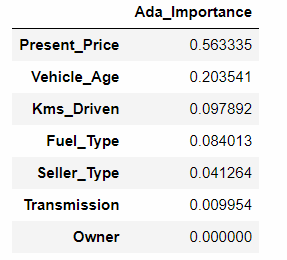

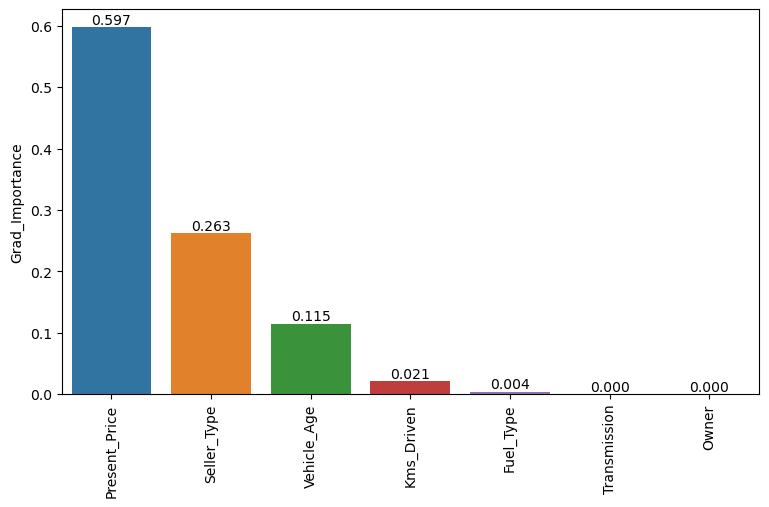

In [171]:
ax = sns.barplot(data=grad_imp_feats, x=grad_imp_feats.index, y='Grad_Importance')
ax.bar_label(ax.containers[0],fmt="%.3f")
plt.xticks(rotation=90);

## XGBoost Regressor

**Overview**
XGBoost stands for eXtreme Gradient Boosting and is an advanced gradient boosting algorithm known for its high performance and speed. It is popular for its effectiveness with large-scale and complex datasets.

**Key Features**
- **High Performance**: Effective in both speed and model accuracy.
- **Scalability**: Capable of handling large datasets.
- **Flexibility**: Offers various customization and configuration options.

**Important Parameters**
- **n_estimators:** The total number of trees.
- **learning_rate:** Controls the size of adjustments made at each step.
- **max_depth:** The maximum depth of the trees.
- **subsample:** The fraction of randomly sampled data used for each tree.
- **colsample_bytree:** The fraction of randomly sampled columns (features) used for each tree.
- **objective:** The target function to optimize.

**Applications**
- **Price Prediction:** Used for predicting prices in real estate, stock markets, and second-hand goods.
- **Demand Forecasting:** Applied in sales, marketing, and supply chain optimization.
- **Risk Assessment:** Utilized in finance and insurance for risk prediction.


**Difference between classication and regression at XGBoost:**
  - For both classification (XGBClassifier) and regression (XGBRegressor), loss functions are determined by the model's `objective` parameter. For classification, options include `binary:logistic`, `multi:softmax`, etc.; for regression, options include `reg:squarederror`, `reg:linear`, etc.  

In [172]:
#!pip install xgboost

In [173]:
from xgboost import XGBRegressor

In [174]:
# Base XGBoost Model
operations = [("OrdinalEncoder", column_trans), ("XGB_model", XGBRegressor(random_state=101))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

# - **In classification**, the `objective` is set to `'binary:logistic'`, while in **regression**, it is `'reg:squarederror'`.
# - Other parameters remain the same for both classification and regression.

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('XGB_model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_by...
                              feature_types=None, gamma=None, gpu_id=None,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, n_estimators=100,
                              n_jobs=None, num_parallel_tree=None,
                              predictor=None, random_state=101, ...))])

In [175]:
train_val(pipe_model, X_train, y_train, X_test, y_test)

,train,test
R2,1.00,0.96
mae,0.00,0.36
mse,0.00,0.30
rmse,0.00,0.55


In [177]:
# CV
operations = [("OrdinalEncoder", column_trans), ("XGB_model", XGBRegressor(random_state=101))]

model = Pipeline(steps=operations)

scores = cross_validate(model, X_train, y_train, scoring=['r2', 
            'neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'], cv =10,
                       return_train_score=True)
pd.DataFrame(scores).iloc[:, 2:].mean()

test_r2                              0.92
train_r2                             1.00
test_neg_mean_absolute_error        -0.48
train_neg_mean_absolute_error       -0.00
test_neg_mean_squared_error         -0.54
train_neg_mean_squared_error        -0.00
test_neg_root_mean_squared_error    -0.70
train_neg_root_mean_squared_error   -0.00
dtype: float64

### XGBoost Model Tuning - Gridsearch

**XGBoost Regressor Main Parameters and Their Functions**

- **n_estimators**: The total number of sequential trees to be built. More trees generally lead to better performance but may increase the risk of overfitting.

- **learning_rate**: Controls the learning rate and the contribution of each tree to the model. Lower values usually lead to slower learning but better generalization.

- **max_depth**: The maximum depth of each tree. Increasing depth allows the model to learn more complex relationships but may increase the risk of overfitting.

- **min_child_weight**: The minimum sum of weights required to create a child node. Used to prevent overfitting.

- **gamma**: The minimum loss reduction required to split a node. Helps prevent unnecessary tree expansion and reduces overfitting.

- **subsample**: The fraction of samples used for building each tree. Smaller values can reduce overfitting, but very low values may increase bias.

- **colsample_bytree**: The fraction of features used for building each tree. Ensures that each tree is built with different subsets of features.

- **alpha**: L1 regularization term (alpha). Reduces model complexity and helps prevent overfitting.

- **reg_lambda**: L2 regularization term (lambda). Reduces model complexity and helps prevent overfitting.

- **scale_pos_weight**: Weight factor for unbalanced classes. Helps the model generalize better on imbalanced datasets.

- **objective**: The optimization objective function. For regression, options include `reg:squarederror` (mean squared error) and `reg:logistic` (logistic regression).

- **booster**: Type of boosting model used. Options include `gbtree` (tree-based models) and `gblinear` (linear models).

**Application Notes**
- The performance of XGBoost heavily depends on the chosen parameters; thus, adjusting parameters according to the dataset and problem is crucial.
- Parameters should be carefully selected to minimize the risk of overfitting.

In [65]:
param_grid = {
    "XGB_model__n_estimators": [40, 50, 100],
    "XGB_model__max_depth": [2, 3],
    "XGB_model__learning_rate": [0.01, 0.05, 0.06],
    "XGB_model__subsample": [0.5, 0.8, 1],
    "XGB_model__colsample_bytree": [0.5, 0.8, 1]
}

In [66]:
operations = [("OrdinalEncoder", column_trans), ("XGB_model", XGBRegressor(random_state=101))]

model = Pipeline(steps=operations)

grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          n_jobs = -1,
                          return_train_score=True).fit(X_train, y_train)

In [67]:
grid_model.best_params_

{'XGB_model__colsample_bytree': 1,
 'XGB_model__learning_rate': 0.06,
 'XGB_model__max_depth': 3,
 'XGB_model__n_estimators': 100,
 'XGB_model__subsample': 0.5}

In [68]:
grid_model.best_score_

-0.5891199312403401

In [69]:
y_pred = grid_model.predict(X_test)
XGB_R2 = r2_score(y_test, y_pred)
XGB_mae = mean_absolute_error(y_test, y_pred)
XGB_mse = mean_squared_error(y_test, y_pred)
XGB_rmse = mean_squared_error(y_test, y_pred, squared=False)
train_val(grid_model, X_train, y_train, X_test, y_test)

,train,test
R2,0.981358,0.972572
mae,0.256540,0.327985
mse,0.128593,0.224564
rmse,0.358599,0.473882


### Feature importance

In [70]:
operations = [("OrdinalEncoder", column_trans),
              ("XGB_model",
               XGBRegressor(n_estimators=100,
                            learning_rate=0.06,
                            max_depth=3,
                            random_state=101,
                            subsample=0.5))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('XGB_model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_by...
                              feature_types=None, gamma=None, gpu_id=None,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.06,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, n_estimators=100,
                              n_jobs=None, num_parallel_tree=None,
                              predictor=None, random_state=101, ...))])

In [71]:
pipe_model["XGB_model"].feature_importances_

array([0.04789568, 0.20523715, 0.01382258, 0.5158294 , 0.05286758,
       0.00647596, 0.15787178], dtype=float32)

In [72]:
pipe_model["OrdinalEncoder"].get_feature_names_out()

array(['ordinalencoder__Fuel_Type', 'ordinalencoder__Seller_Type',
       'ordinalencoder__Transmission', 'remainder__Present_Price',
       'remainder__Kms_Driven', 'remainder__Owner',
       'remainder__Vehicle_Age'], dtype=object)

In [73]:
new_features

['Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Present_Price',
 'Kms_Driven',
 'Owner',
 'Vehicle_Age']

In [74]:
imp_feats = pd.DataFrame(data=pipe_model["XGB_model"].feature_importances_, columns=['XGB_Importance'], index=new_features)
xgb_imp_feats = imp_feats.sort_values('XGB_Importance', ascending=False)
xgb_imp_feats

,XGB_Importance
Present_Price,0.515829
Seller_Type,0.205237
Vehicle_Age,0.157872
Kms_Driven,0.052868
Fuel_Type,0.047896
Transmission,0.013823
Owner,0.006476


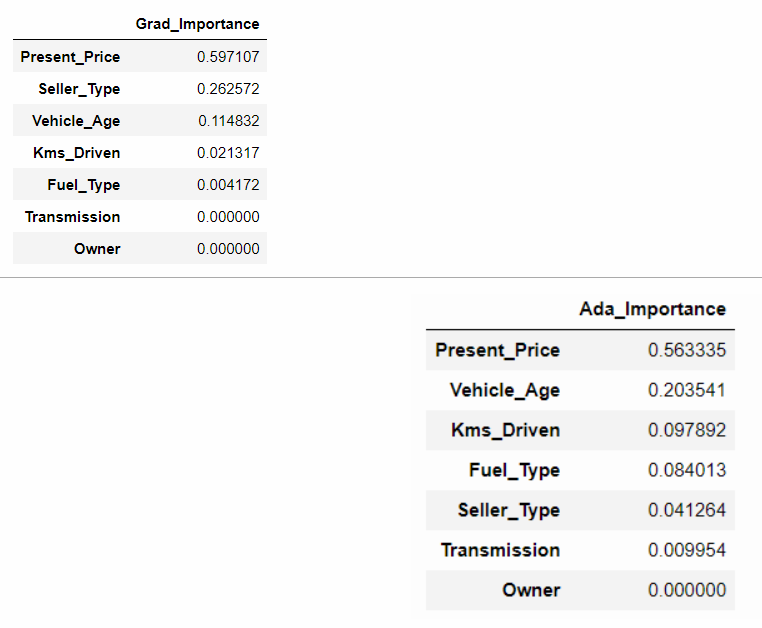

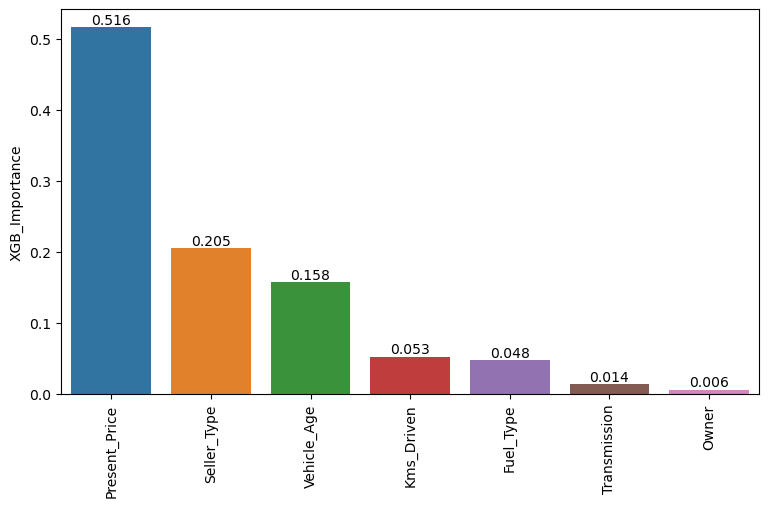

In [75]:
ax = sns.barplot(data=xgb_imp_feats, x=xgb_imp_feats.index, y='XGB_Importance')
ax.bar_label(ax.containers[0],fmt="%.3f")
plt.xticks(rotation=90);

In [76]:
pd.concat([ada_imp_feats, grad_imp_feats, xgb_imp_feats], axis=1)

,Ada_Importance,Grad_Importance,XGB_Importance
Present_Price,0.563335,0.597107,0.515829
Vehicle_Age,0.203541,0.114832,0.157872
Kms_Driven,0.097892,0.021317,0.052868
Fuel_Type,0.084013,0.004172,0.047896
Seller_Type,0.041264,0.262572,0.205237
Transmission,0.009954,0.000000,0.013823
Owner,0.000000,0.000000,0.006476


## LightGBM Regressor

**Overview**
LightGBM is a gradient boosting framework developed by Microsoft that is known for its speed and efficiency. It stands out due to its fast training times and lower memory consumption on large datasets. It also has the ability to handle categorical features directly.

**Key Features**
- **Speed and Efficiency**: Fast training and low memory usage on large datasets.
- **Direct Handling of Categorical Features**: Can process categorical data without requiring feature engineering.
- **Flexibility**: Customizable with various loss functions and hyperparameters.

**Important Parameters**

- **num_leaves**: The maximum number of leaves in each tree. Controls the complexity of the model.

- **learning_rate**: Determines how fast the model learns in each iteration. Lower values generally provide better generalization performance.

- **n_estimators**: The total number of trees to be built. More trees typically lead to better performance.

- **max_depth**: The maximum depth of the trees. Deeper trees can make the model more complex.

- **min_data_in_leaf**: The minimum number of data points required in a leaf. Helps prevent overfitting.

- **bagging_fraction**: The fraction of data samples used in each iteration. Reduces overfitting and improves model robustness.

- **feature_fraction**: The fraction of features used in each iteration. Allows the model to train on different feature subsets.

- **lambda_l1, lambda_l2**: L1 and L2 regularization terms, respectively. Reduce model complexity and help prevent overfitting.

- **objective**: The optimization objective function. Examples include regression, regression_l1, huber, and fair.

- **boosting_type**: The type of boosting to be used. Options include gbdt (traditional Gradient Boosting Decision Tree) and dart (Dropouts meet Multiple Additive Regression Trees).

**Application Notes**
- LightGBM is particularly faster than XGBoost and other gradient boosting frameworks, especially on large and high-dimensional datasets.
- Proper parameter tuning can significantly impact the model's performance.

In [83]:
from lightgbm import LGBMRegressor

In [84]:
operations = [("OrdinalEncoder", column_trans), ("LGBM_model", LGBMRegressor(random_state=101, objective='regression'))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 140
[LightGBM] [Info] Number of data points in the train set: 218, number of used features: 6
[LightGBM] [Info] Start training from score 3.390826
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('LGBM_model',
                 LGBMRegressor(objective='regression', random_state=101))])

In [85]:
train_val(pipe_model, X_train, y_train, X_test, y_test)

,train,test
R2,0.970720,0.971920
mae,0.292468,0.348476
mse,0.201981,0.229899
rmse,0.449423,0.479478


In [86]:
operations = [("OrdinalEncoder", column_trans),
              ("LGBM_model",
               LGBMRegressor(random_state=101, objective='regression'))]

model = Pipeline(steps=operations)
scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=[
                            'r2', 'neg_mean_absolute_error',
                            'neg_mean_squared_error',
                            'neg_root_mean_squared_error'
                        ],
                        cv=10,
                        return_train_score=True)

pd.DataFrame(scores).mean()[2:]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 130
[LightGBM] [Info] Number of data points in the train set: 196, number of used features: 6
[LightGBM] [Info] Start training from score 3.373980
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 132
[LightGBM] [Info] Number of data points in the train set: 196, number of used features: 5
[LightGBM] [Info] Start training from score 3.296276
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

test_r2                              0.909349
train_r2                             0.964153
test_neg_mean_absolute_error        -0.471325
train_neg_mean_absolute_error       -0.311360
test_neg_mean_squared_error         -0.560229
train_neg_mean_squared_error        -0.247015
test_neg_root_mean_squared_error    -0.711584
train_neg_root_mean_squared_error   -0.496218
dtype: float64

### LightGBM Model Tuning - Gridsearch

**LightGBM Regressor Key Parameters and Functions**

- **boosting_type**: Specifies the type of boosting used. 'gbdt' (gradient boosting decision tree) is typically the default and most commonly used type.

- **num_leaves**: Specifies the maximum number of leaves in a tree. Higher values increase model complexity but may lead to overfitting.

- **max_depth**: Determines the maximum depth of the tree. -1 means unlimited depth. Increased depth makes the model more complex.

- **learning_rate**: Controls the learning rate. A lower learning rate can improve generalization but requires more iterations for convergence.

- **n_estimators**: Specifies the number of trees to be used in training. More trees generally lead to better performance but increase computation time and may cause overfitting.

- **subsample_for_bin**: Determines the number of samples used for histogram construction. Larger values lead to more accurate but slower computations.

- **objective**: Specifies the objective function for optimization.

- **class_weight**: Defines class weights, often used in imbalanced datasets.

- **min_split_gain**: The minimum gain required to make a split. Larger values can help prevent overfitting.

- **min_child_weight**: The minimum weight required for a leaf. Larger values make the model more conservative.

- **min_child_samples**: The minimum number of samples required in a leaf.

- **subsample**: The fraction of samples used in each iteration. Helps prevent overfitting.

- **subsample_freq**: Specifies the frequency of subsampling.

- **colsample_bytree**: The fraction of features used in each iteration.

- **reg_alpha**: L1 regularization term.

- **reg_lambda**: L2 regularization term.

- **random_state**: A seed value for randomness.

- **n_jobs**: The number of parallel threads to use.

- **importance_type**: Method used to determine feature importance.

- **LightGBM:**
  - For both LGBMClassifier and LGBMRegressor, the loss functions are configured using the `objective` parameter. For classification, options include `binary`, `multiclass`; for regression, options include `regression`, `huber`, `quantile`, among others.

In [89]:
param_grid = {
    'LGBM_model__learning_rate': [0.01, 0.05, 0.1],
    'LGBM_model__n_estimators': [100, 200, 500],
    'LGBM_model__max_depth': [3, 5],
    "LGBM_model__num_leaves": [8, 32, 256],  # Values corresponding to 2^max_depth mean to take the power of two raised to the max_depth.
    'LGBM_model__subsample': [0.8, 1.0],
    'LGBM_model__colsample_bytree': [0.8, 0.9, 1.0]
}

**The Importance of `num_leaves` and `max_depth` Parameters in LightGBM**

In LightGBM, the `num_leaves` parameter specifies the maximum number of leaves in each tree, directly influencing the model's complexity. The `max_depth` parameter, on the other hand, determines the maximum depth of the tree. However, there should be a balance between these two parameters.

**Tuning the `num_leaves` Parameter**
- The `num_leaves` parameter is typically set to be smaller than or equal to \(2^{\text{max_depth}}\). This is based on the idea that each level of the tree can have up to two branches.
- If `max_depth` is set but `num_leaves` is not configured (or is set to a very high value), LightGBM may issue warnings about potential deviations from the expected model performance.

**Achieving Balance**
- Ideally, the value of `num_leaves` should be less than or equal to \(2^{\text{max_depth}}\). However, creating very deep trees might lead to overfitting.
- Therefore, it is crucial to adjust the `num_leaves` parameter carefully and find a suitable value for the model. This should be considered during the hyperparameter optimization process.

**Practical Application**
When tuning your model and performing hyperparameter optimization, take into account the balance between these two parameters. A well-balanced setting will enhance the model's generalization capability and protect against overfitting.

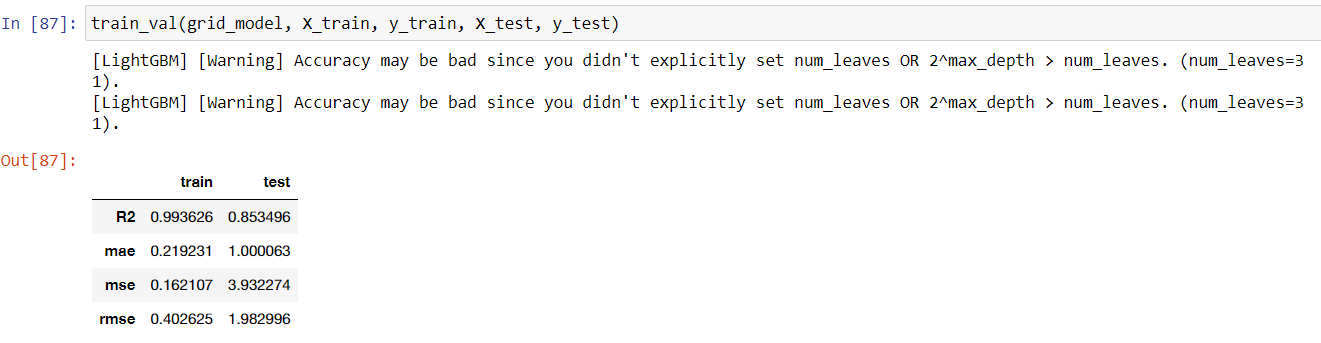

In [178]:
# CV
operations = [("OrdinalEncoder", column_trans), ("LGBM_model", LGBMRegressor(random_state=101, objective='regression', verbose=-1))]

model = Pipeline(steps=operations)

grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          n_jobs = -1,
                          return_train_score=True).fit(X_train, y_train)

ValueError: Invalid parameter 'GB_model' for estimator Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('LGBM_model',
                 LGBMRegressor(objective='regression', random_state=101,
                               verbose=-1))]). Valid parameters are: ['memory', 'steps', 'verbose'].

In [ ]:
grid_model.best_params_

In [ ]:
grid_model.best_score_

In [ ]:
train_val(grid_model, X_train, y_train, X_test, y_test)

In [ ]:
y_pred = grid_model.predict(X_test)
LGBM_R2 = r2_score(y_test, y_pred)
LGBM_mae = mean_absolute_error(y_test, y_pred)
LGBM_mse = mean_squared_error(y_test, y_pred)
LGBM_rmse = mean_squared_error(y_test, y_pred, squared=False)
train_val(grid_model, X_train, y_train, X_test, y_test)

### Feature Importance

In [91]:
operations = [("OrdinalEncoder", column_trans),
              ("LGBM_model",
               LGBMRegressor(random_state=101,
                             objective='regression',
                             colsample_bytree=0.9,
                             learning_rate=0.05,
                             max_depth=3,
                             subsample=0.8,
                             n_estimators=200,
                             verbose=-1))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('LGBM_model',
                 LGBMRegressor(colsample_bytree=0.9, learning_rate=0.05,
                               max_depth=3, n_estimators=200,
                               objective='regression', random_state=101,
                               subsample=0.8, verbose=-1))])

In [92]:
pipe_model["LGBM_model"].feature_importances_

array([ 39,  22,  22, 305, 204,   0, 200])

In [93]:
imp_feats = pd.DataFrame(data=pipe_model["LGBM_model"].feature_importances_, columns=['LGBM_Importance'], index=new_features)
lgbm_imp_feats = imp_feats.sort_values('LGBM_Importance', ascending=False)
lgbm_imp_feats

,LGBM_Importance
Present_Price,305
Kms_Driven,204
Vehicle_Age,200
Fuel_Type,39
Seller_Type,22
Transmission,22
Owner,0


In [94]:
# We are comparing feature importace results of all models
pd.concat([ada_imp_feats, grad_imp_feats, xgb_imp_feats, lgbm_imp_feats], axis=1)

,Ada_Importance,Grad_Importance,XGB_Importance,LGBM_Importance
Present_Price,0.563335,0.597107,0.515829,305
Vehicle_Age,0.203541,0.114832,0.157872,200
Kms_Driven,0.097892,0.021317,0.052868,204
Fuel_Type,0.084013,0.004172,0.047896,39
Seller_Type,0.041264,0.262572,0.205237,22
Transmission,0.009954,0.000000,0.013823,22
Owner,0.000000,0.000000,0.006476,0


## New model

In [95]:
# We coosed the best feautres for compare the results 
X2 = df2[["Vehicle_Age",  "Present_Price"]]

In [96]:
X2.head()

,Vehicle_Age,Present_Price
0,10,5.59
1,11,9.54
2,7,9.85
3,13,4.15
4,10,6.87


In [97]:
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.1, random_state=101)

In [98]:
model = XGBRegressor(random_state=101, objective="reg:squarederror")

In [99]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=101, ...)

In [100]:
train_val(model, X_train, y_train, X_test, y_test)

,train,test
R2,0.994038,0.971825
mae,0.083792,0.364592
mse,0.041614,0.245685
rmse,0.203994,0.495667


In [101]:
model = XGBRegressor(random_state=101, objective="reg:squarederror")
scores = cross_validate(model, X_train, y_train, scoring=['r2', 
            'neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'], cv =10)
pd.DataFrame(scores).iloc[:, 2:].mean()

test_r2                             0.919166
test_neg_mean_absolute_error       -0.465477
test_neg_mean_squared_error        -0.527847
test_neg_root_mean_squared_error   -0.711711
dtype: float64

## Gridsearch for new XGBoost model

In [102]:
param_grid = {"n_estimators":[100, 300,500],'max_depth':[3,5,6,7], "learning_rate": [0.05, 0.1, 0.2],
             "subsample":[0.5, 1], "colsample_bytree":[0.5, 1]}

In [103]:
model = XGBRegressor(random_state=101, objective="reg:squarederror")
grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          n_jobs = -1)

In [104]:
grid_model.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None, gpu_id=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None,...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None, n_estimators=100,
                                    n_jobs=None, num_parallel_tree=None,
                                    predictor=None, random_state=101, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.5, 1],
                         'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 6, 7],
                         'n_estimators': [100, 300, 500],
                         'subsample': [0.5, 1]},
             scoring='neg_root_mean_squared_error')

In [105]:
grid_model.best_params_

{'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 3,
 'n_estimators': 100,
 'subsample': 0.5}

In [106]:
grid_model.best_score_

-0.5972703875660366

In [107]:
train_val(grid_model, X_train, y_train, X_test, y_test)

,train,test
R2,0.979428,0.983145
mae,0.269110,0.280864
mse,0.143590,0.146969
rmse,0.378933,0.383366


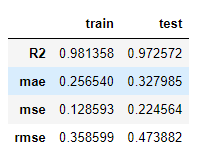

# Model Comparison

In [108]:
compare = pd.DataFrame({"Model": ["AdaBoost", "GradientBoost", "XGBoost", "LightGBM"],
                        "R2": [ada_R2, grad_R2, XGB_R2, LGBM_R2],
                        "MAE": [ada_mae, grad_mae, XGB_mae, LGBM_mae],
                        "MSE": [ada_mse, grad_mse, XGB_mse, LGBM_mse],
                        "RMSE": [ada_rmse, grad_rmse, XGB_rmse, LGBM_rmse]})

def labels(ax):
    for p in ax.patches:
        width = p.get_width()                        
        ax.text(width,                              
                p.get_y() + p.get_height() / 2,     
                '{:.3f}'.format(width),             
                ha='left',                         
                va='center')                       
    
plt.figure(figsize=(14, 10))

plt.subplot(411)
compare = compare.sort_values(by="R2", ascending=False)
ax = sns.barplot(x="R2", y="Model", data=compare, palette="Blues_d")
labels(ax)
plt.title('R2 Scores')

plt.subplot(412)
compare = compare.sort_values(by="MAE", ascending=False)
ax = sns.barplot(x="MAE", y="Model", data=compare, palette="Blues_d")
labels(ax)
plt.title('MAE Scores')

plt.subplot(413)
compare = compare.sort_values(by="MSE", ascending=False)
ax = sns.barplot(x="MSE", y="Model", data=compare, palette="Blues_d")
labels(ax)
plt.title('MSE Scores')

plt.subplot(414)
compare = compare.sort_values(by="RMSE", ascending=False)
ax = sns.barplot(x="RMSE", y="Model", data=compare, palette="Blues_d")
labels(ax)
plt.title('RMSE Scores')

plt.tight_layout()
plt.show()

NameError: name 'LGBM_R2' is not defined

# Final Model & Prediction

In [ ]:
cat_features

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

column_trans = make_column_transformer((ord_enc, cat_features),
                                       remainder='passthrough')

operations = [("OrdinalEncoder", column_trans),
              ("XGB_model",
               XGBRegressor(n_estimators=100,
                            learning_rate=0.1,
                            max_depth=3,
                            random_state=101,
                            subsample=0.5))]

pipe_model = Pipeline(steps=operations)
pipe_model.fit(X, y)

In [ ]:
pd.DataFrame(column_trans.fit_transform(X)).head()

In [ ]:
samples = {"Present_Price": [9, 7.2],
           "Kms_Driven": [20000, 40000],
           "Fuel_Type":["Petrol", "Diesel"],
           'Seller_Type':['Individual', 'Dealer'],
           'Transmission': ['Automatic', 'Manual'],
           "Owner":[0,2],
           "Vehicle_Age":[2, 7]}

In [ ]:
df_samples = pd.DataFrame(samples)
df_samples

In [ ]:
pipe_model.predict(df_samples)

# Lazy Predict Library

https://medium.com/machine-learning-t%C3%BCrkiye/lazy-predict-library-c90b5ab04f1d


**LazyPredict is a Python library used for quickly testing and comparing machine learning models. This library is designed to save time during the model selection phase, particularly in data science and machine learning projects.**

### **How It Works**

- **Automatic Model Testing:** LazyPredict allows you to quickly see which model performs best on your dataset by automatically testing numerous classification or regression models.
- **Ease of Use:** It operates with minimal code, enabling users to test many models with a single command.
- **Result Comparison:** You can compare the performance of various models based on metrics such as accuracy and F1 score, and obtain a report.

### **Advantages**

1. **Time Savings:** Instead of testing multiple machine learning models individually, LazyPredict automates the process, saving you time.
2. **Starting Point:** It quickly identifies which models are promising for your dataset, providing a starting point for more detailed optimization and analysis.
3. **Ease of Use:** It simplifies complex model selection processes, making it user-friendly, especially for those new to machine learning.
4. **Wide Model Support:** Supports many popular classification and regression models, allowing you to easily test different types of models.

### **Disadvantages**

1. **Lack of Detailed Tuning:** LazyPredict evaluates basic model performance but does not adjust model hyperparameters in detail. Manual tuning may be necessary to achieve optimal performance.
2. **Limited for Special Cases:** Some specialized or complex datasets or modeling requirements may not be fully addressed by LazyPredict’s automated approach.
3. **Performance Evaluation:** The performance metrics obtained are limited to default parameters. Even the best model identified may be improved further with additional tuning.

LazyPredict is an excellent tool for quickly comparing models in the early stages of your data science projects. However, more detailed work may be required to further develop and optimize your model in the later stages of the project.

### **Installation**

To install the LazyPredict library, use the following pip command:

```python
!pip install lazypredict
```

### **Basic Usage**

The basic use of LazyPredict involves testing various models on a dataset and comparing their performances. Here is an example of how to use it for a classification problem:

```python
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load the data
data = load_iris()
X = data.data
y = data.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Print the model performance
print(models)
```

This code tests various classification models on the Iris dataset and returns a DataFrame summarizing the performance of each model.

### **Evaluation and Results**

LazyPredict presents the results in a table format, including metrics such as accuracy, F1 score, and processing time for each model. This helps you quickly compare different algorithms and select the most suitable one for your project.

In [111]:
#!pip install lazypredict

In [ ]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load the data
data = load_iris()
X = data.data
y = data.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Print the model performance
print(models)

In [ ]:
from lazypredict.Supervised import LazyRegressor

reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models)